In [1]:
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
train = np.load("./data/processed/dataset_train.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]          # int {0,1}

full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = full["X"]
K0_full = full["K0"]


In [3]:
def fit_scaler(X_train):
    scaler = StandardScaler()
    return scaler.fit(X_train)

In [4]:
def run_supervised_pipeline(
    model,
    X_train, y_train,
    X_full
):
    # --- preprocessing ---
    scaler = fit_scaler(X_train)
    X_train_scaled = scaler.transform(X_train)

    # --- train ---
    model.fit(X_train_scaled, y_train)

    train_score = model.score(X_train_scaled, y_train)

    # --- classify FULL dataset ---
    X_full_scaled = scaler.transform(X_full)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_full_scaled)[:, 1]
    else:
        scores = model.decision_function(X_full_scaled)
        P_A = 1 / (1 + np.exp(-scores))  # sigmoid

    return {
        "model": model,
        "scaler": scaler,
        "train_score": train_score,
        "P_A": P_A
    }


In [5]:
def phase_analysis(P_A, K0_full):
    df = pd.DataFrame({
        "K0": K0_full,
        "P_A": P_A
    })

    grouped = df.groupby("K0")

    mean_P = grouped.mean()["P_A"]
    var_P  = grouped.var()["P_A"]

    return mean_P, var_P

In [6]:
def plot_phase_results(mean_P, var_P, title_prefix=""):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    ax[0].plot(mean_P.index, mean_P.values, "o-")
    ax[0].set_xlabel("K0")
    ax[0].set_ylabel("⟨P(A)⟩")
    ax[0].set_title(f"{title_prefix} Mean probability")

    ax[1].plot(var_P.index, var_P.values, "o-")
    ax[1].set_xlabel("K0")
    ax[1].set_ylabel("Var(P(A))")
    ax[1].set_title(f"{title_prefix} Susceptibility")

    for a in ax:
        a.grid(True)

    plt.show()


In [7]:
def plot_phase_results(mean_P, var_P, title_prefix=""):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    ax[0].plot(mean_P.index, mean_P.values, "o-")
    ax[0].set_xlabel("K0")
    ax[0].set_ylabel("⟨P(A)⟩")
    ax[0].set_title(f"{title_prefix} Mean probability")

    ax[1].plot(var_P.index, var_P.values, "o-")
    ax[1].set_xlabel("K0")
    ax[1].set_ylabel("Var(P(A))")
    ax[1].set_title(f"{title_prefix} Susceptibility")

    for a in ax:
        a.grid(True)

    plt.show()



In [8]:
def select_transition_region(X, K0, K0_min=4.73, K0_max=4.86):
    mask = (K0 >= K0_min) & (K0 <= K0_max)
    return X[mask], K0[mask]


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def run_knn_analysis(X_train, y_train, X_full, K0_full, thin_train=5, thin_mid=20):
    print("\n=== kNN (local analysis) ===")

    # --- preprocessing ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # --- thinning TRAIN ---
    X_train_knn = X_train_scaled[::thin_train]
    y_train_knn = y_train[::thin_train]

    knn = KNeighborsClassifier(n_neighbors=15)
    knn.fit(X_train_knn, y_train_knn)

    acc = accuracy_score(y_train_knn, knn.predict(X_train_knn))
    print(f"kNN train accuracy (thinned): {acc:.4f}")

    # --- transition region ---
    X_mid, K0_mid = select_transition_region(X_full, K0_full)

    # --- thinning MID ---
    X_mid = X_mid[::thin_mid]
    K0_mid = K0_mid[::thin_mid]

    X_mid_scaled = scaler.transform(X_mid)

    t0 = time.perf_counter()
    P_A = knn.predict_proba(X_mid_scaled)[:, 1]
    elapsed = time.perf_counter() - t0

    mean_P, var_P = phase_analysis(P_A, K0_mid)

    print(f"kNN transition-only time: {elapsed:.2f} s")
    plot_phase_results(mean_P, var_P, "kNN (transition, thinned)")

    return {
        "train_score": acc,
        "time_sec": elapsed,
        "mean_P": mean_P,
        "var_P": var_P
    }



=== kNN (local analysis) ===
kNN train accuracy (thinned): 1.0000
kNN transition-only time: 46.06 s


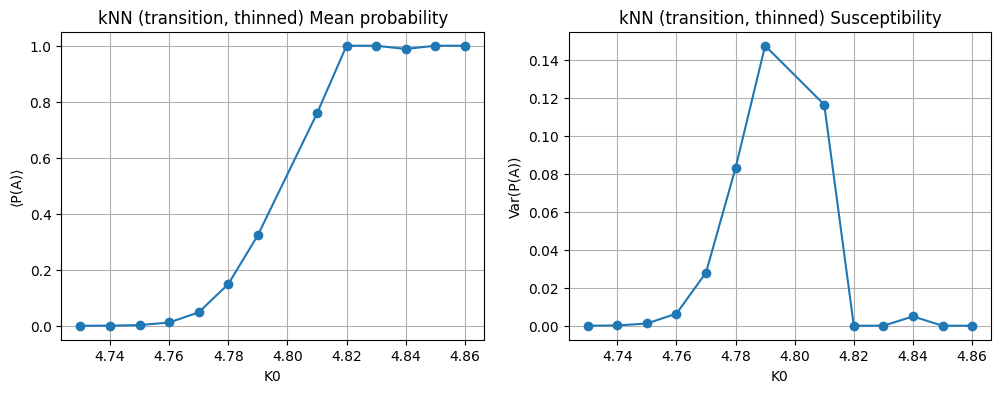

In [10]:
knn_result = run_knn_analysis(X_train, y_train, X_full, K0_full)


In [32]:
NN_CONFIGS = {
      "NN_500_tanh_reg_e1": dict(
        hidden_layer_sizes=(500,),
        activation="tanh",
        alpha=1e-1
    ), 
   "NN_500_tanh_reg": dict(
        hidden_layer_sizes=(500,),
        activation="tanh",
        alpha=1e-2
    ), 
    "NN_50_tanh_reg": dict(
        hidden_layer_sizes=(50,),
        activation="tanh",
        alpha=1e-2
    ),
     "NN_20_tanh_reg": dict(
        hidden_layer_sizes=(20,),
        activation="tanh",
        alpha=1e-2
    ),
    "NN_small_tanh_reg": dict(
        hidden_layer_sizes=(10,),
        activation="tanh",
        alpha=1e-2
    ),
    "NN_smaller_tanh_strong_reg": dict(
        hidden_layer_sizes=(5,),
        activation="tanh",
        alpha=1e-1
    ),
    "NN_small_relu_reg": dict(
        hidden_layer_sizes=(5,),
        activation="relu",
        alpha=1e-2
    ),
}

In [35]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import time

def run_single_nn(
    name,
    nn_params,
    X_train, y_train,
    X_full, K0_full,
    thin_train=10,
    thin_mid=20,
    K0_min=4.67,
    K0_max=4.93
):
    print(f"\n=== {name} ===")

    # --- thinning TRAIN ---
    #X_nn = X_train[::thin_train]
    #y_nn = y_train[::thin_train]

    X_nn = X_train
    y_nn = y_train
    scaler = StandardScaler()
    X_nn_scaled = scaler.fit_transform(X_nn)

    nn = MLPClassifier(
        solver="adam",
        max_iter=300,
        early_stopping=True,
        random_state=0,
        **nn_params
    )

    nn.fit(X_nn_scaled, y_nn)

    acc = nn.score(X_nn_scaled, y_nn)
    print(f"Train accuracy (thinned): {acc:.4f}")

    # --- transition region ---
    X_mid, K0_mid = select_transition_region(
        X_full, K0_full,
        K0_min=K0_min,
        K0_max=K0_max
    )

    X_mid = X_mid[::thin_mid]
    K0_mid = K0_mid[::thin_mid]

    X_mid_scaled = scaler.transform(X_mid)

    t0 = time.perf_counter()
    P_A = nn.predict_proba(X_mid_scaled)[:, 1]
    elapsed = time.perf_counter() - t0

    mean_P, var_P = phase_analysis(P_A, K0_mid)

    print(f"Transition-only time: {elapsed:.2f} s")

    plot_phase_results(mean_P, var_P, f"{name}")

    return {
        "name": name,
        "train_score": acc,
        "time_sec": elapsed,
        "mean_P": mean_P,
        "var_P": var_P
    }


In [36]:
def run_nn_grid(
    X_train, y_train,
    X_full, K0_full,
    nn_configs
):
    results = {}

    for name, params in nn_configs.items():
        try:
            res = run_single_nn(
                name,
                params,
                X_train, y_train,
                X_full, K0_full
            )
            results[name] = res
        except Exception as e:
            print(f"\n⚠️ {name} failed: {e}")

    return results



=== NN_500_tanh_reg_e1 ===
Train accuracy (thinned): 1.0000
Transition-only time: 11.34 s


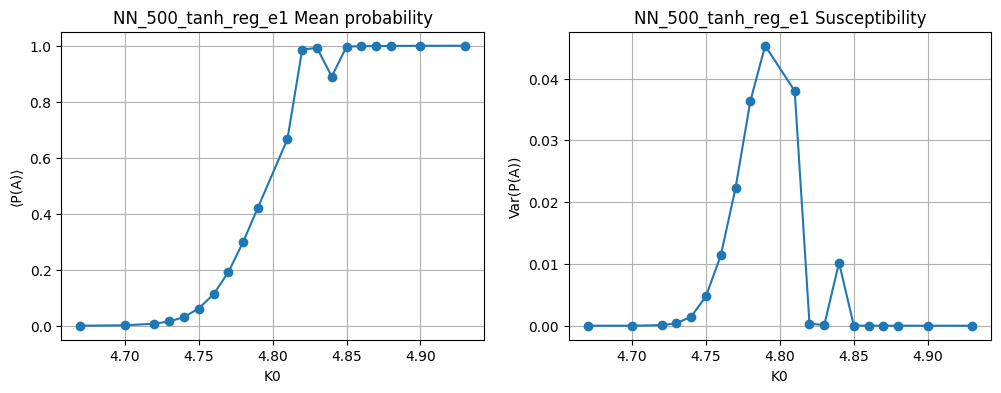


=== NN_500_tanh_reg ===
Train accuracy (thinned): 1.0000
Transition-only time: 10.19 s


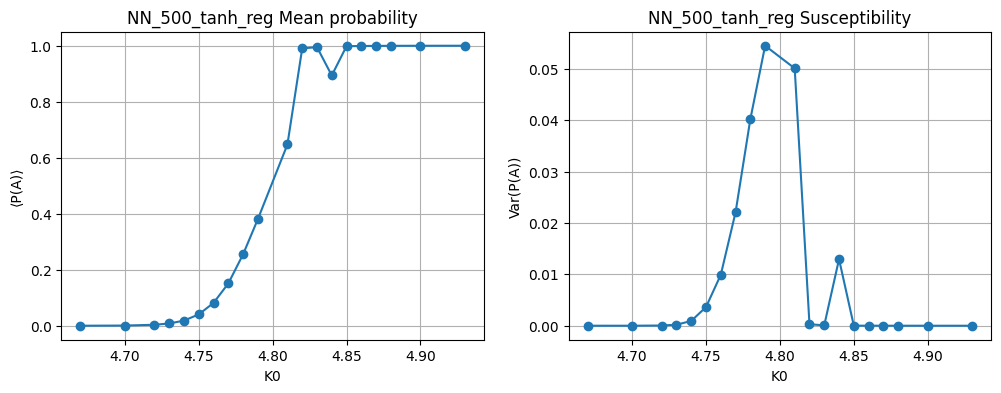


=== NN_50_tanh_reg ===
Train accuracy (thinned): 1.0000
Transition-only time: 1.14 s


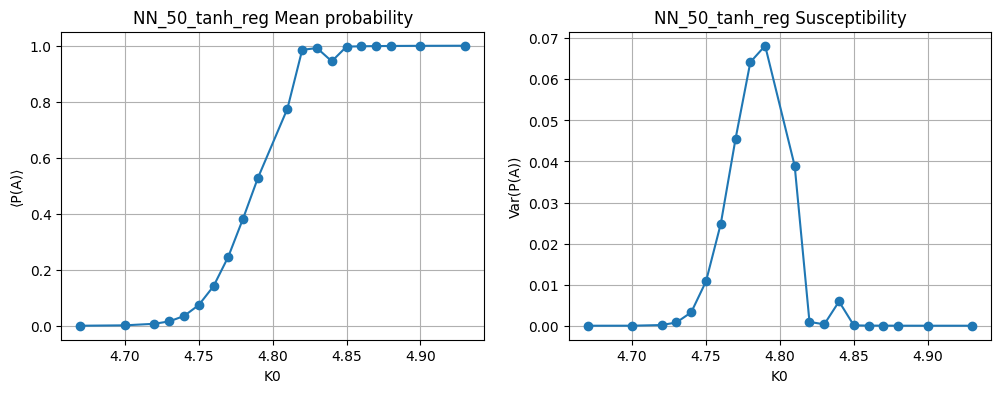


=== NN_20_tanh_reg ===
Train accuracy (thinned): 1.0000
Transition-only time: 0.54 s


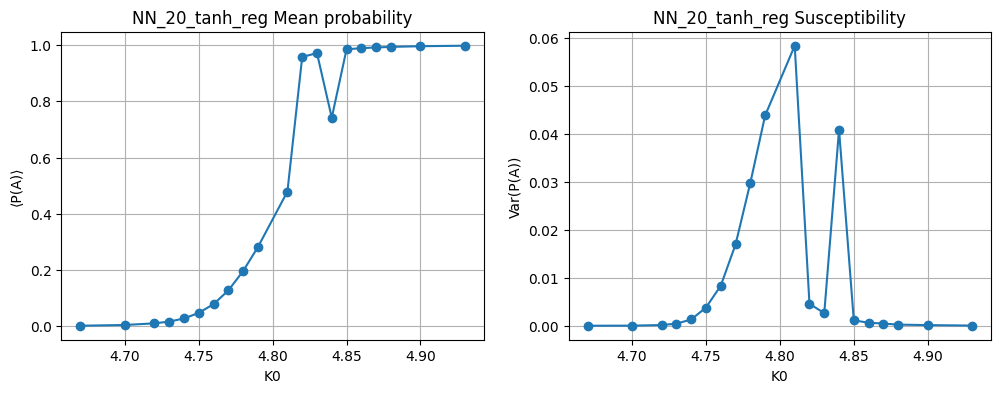


=== NN_small_tanh_reg ===
Train accuracy (thinned): 1.0000
Transition-only time: 0.36 s


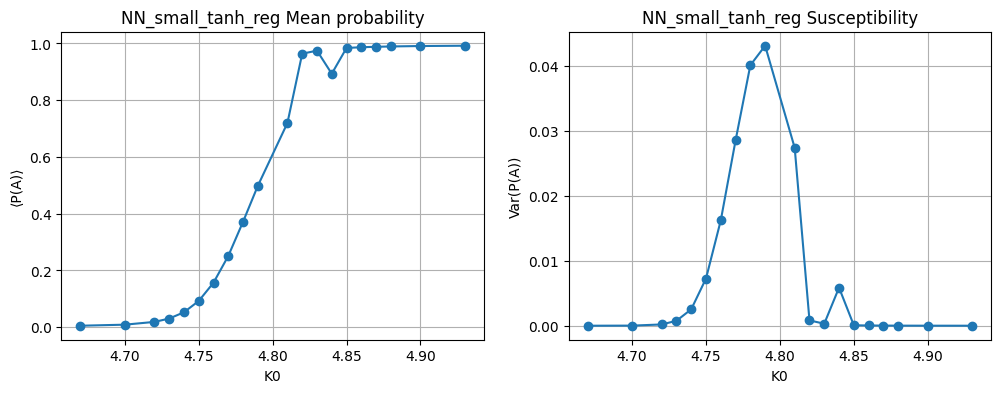


=== NN_smaller_tanh_strong_reg ===
Train accuracy (thinned): 1.0000
Transition-only time: 0.27 s


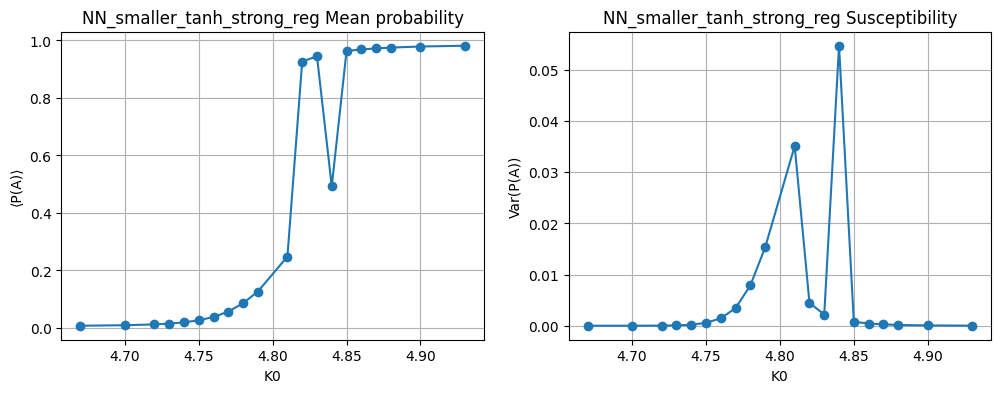


=== NN_small_relu_reg ===
Train accuracy (thinned): 1.0000
Transition-only time: 0.18 s


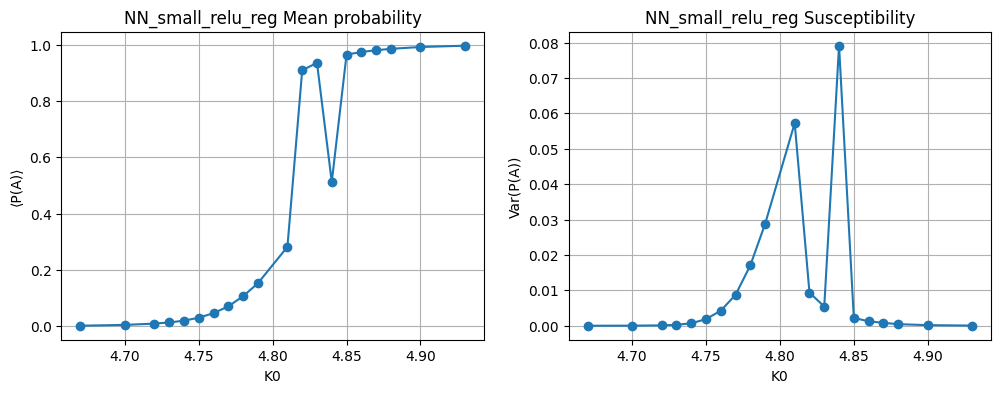

In [37]:
nn_results = run_nn_grid(
    X_train, y_train,
    X_full, K0_full,
    NN_CONFIGS
)


In [38]:
import pandas as pd

summary = pd.DataFrame({
    name: {
        "train_accuracy": res["train_score"],
        "time_sec": res["time_sec"]
    }
    for name, res in nn_results.items()
}).T

summary


,train_accuracy,time_sec
NN_500_tanh_reg_e1,1.0,11.342141
NN_500_tanh_reg,1.0,10.194343
NN_50_tanh_reg,1.0,1.144182
NN_20_tanh_reg,1.0,0.544064
NN_small_tanh_reg,1.0,0.363626
NN_smaller_tanh_strong_reg,1.0,0.267668
NN_small_relu_reg,1.0,0.178246


z nn był problem, poniewaz wyrzucało mi kernela, ale stopniowo zwiększając rozmiar danych wszystko się udało -> NN jest dobre
podobnie z kNN, tutaj bardzo długo czekałem na jakikolwiek response, stąd skrócony dataset został przetestowany